In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score
from sklearn.model_selection import LeaveOneOut,KFold
from itertools import product

In [ ]:
data = pd.read_excel('Microwave_Pyrolysis_Dataset.xlsx')
data = data.drop(columns = ['No.','Ref', 'Biomass','Catalyst'])

X= data.drop(['Gas yield','Oil yield', 'Char yield'], axis =1, inplace = False)
y = data['Gas yield']

In [ ]:
para = {
    'n_estimators': [50,100,150],
    'learning_rate': [0.1,0.01,0.2]}

para_comb = list(product(para['n_estimators']
                         ,para['learning_rate']))

In [ ]:
mse_hist =[]
best_para = None
bmse = float('inf')


for n_estimators,learning_rate in para_comb:
    model = AdaBoostRegressor(n_estimators = n_estimators,
                          learning_rate = learning_rate,random_state = 42)
    loo = LeaveOneOut()

    mse_hist =[]
    for train_idx,test_idx in loo.split(y):
      x_train,y_train,x_test,y_test=X.iloc[train_idx],y.iloc[train_idx],X.iloc[test_idx],y.iloc[test_idx]

      model.fit(x_train,y_train)
      y_pred =model.predict(x_test)
      mse =mean_squared_error(y_test,y_pred)
      mse_hist.append(mse)

    mse= np.mean(mse_hist)

    if mse < bmse:
      bmse = mse
      best_para= {
                   'n_estimators' : n_estimators,
                   'learning_rate': learning_rate

      }


{'n_estimators': 150, 'learning_rate': 0.2}
MSE: 58.60089320151255
MAE: 6.312594849571213
R2: 0.7469752995229586


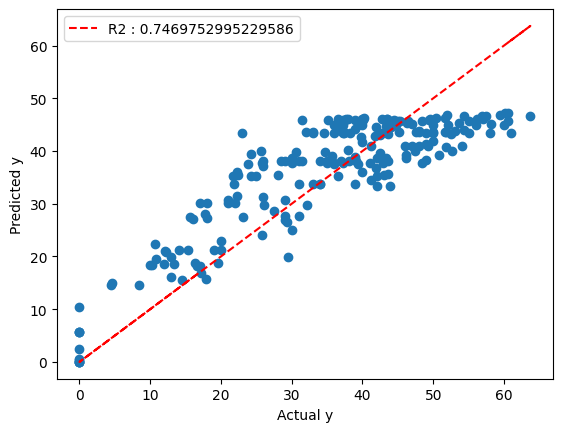

In [ ]:
best_model = AdaBoostRegressor(**best_para,random_state=42)

best_model.fit(X,y)
y_pred = best_model.predict(X)

mse = mean_squared_error(y,y_pred)
mae = mean_absolute_error(y,y_pred)
r2 = r2_score(y,y_pred)

print(best_para)
print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'R2: {r2}')

plt.plot(y,y,'r--',label = 'Ideal')
plt.scatter(y,y_pred,label= 'Predicted values')
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.legend([f'R2 : {r2}'])
plt.show()